In [1]:
import os

file_path = "../data/csv/recalls_combined.csv"
print(os.path.exists(file_path))

import pandas as pd

recalls_df = pd.read_csv(file_path)
recalls_df.head()

True


,year,date,recall_ref,product_name,inn_name,batch_no,manufacturer,reason
0,2016,11/12/2013,NaN,Biomol tablets,Paracetamol,All batches,Biodeal Laboratories Ltd,Color change and moulding
1,2016,24/09/2015,NaN,Beta gripe water,Gripe water,"11A, 2A, 6A, 7A, 11A",Beta Healthcare International,the batches had problems of floculation
2,2016,15/06/2016,NaN,OPVERO,Oral Polio Vaccine,M5169-1,Sanofi Aventis,To replace trivalent with bivalent OPV
3,2017,29/03/2017,NaN,Clopidogrel with Aspirin,Clopidogrel and Aspirin,E31614002,Unicure Remedies,"The product failed dissolution test, assay tes..."
4,2017,05/04/2017,NaN,Dulcolax 5mg,Bisacodyl,160697,Boehringer,Detected Out of specification for dissolution ...


In [2]:
df = recalls_df.copy()

def classify_country(value):
    if pd.isna(value):
        return None
    elif "Kenya" in value:
        return "Kenya"
    elif "," in value:
        return "Other countries"
    else:
        return None #no other countries mentioned
    
df['country_group'] = df['manufacturer'].apply(classify_country)

In [3]:
unclassified_df = recalls_df[df['country_group'].isna()]

unclassified_manufacturers = unclassified_df['manufacturer'].unique()

print("Number of unclassififed manufacturers:", len(unclassified_manufacturers))

print(unclassified_manufacturers)


Number of unclassififed manufacturers: 53
['Biodeal Laboratories Ltd' 'Beta Healthcare International'
 'Sanofi Aventis' 'Unicure Remedies' 'Boehringer' 'Astra Lifecare Ltd'
 'Shree Krishna Keshav Lab Ltd' 'Theon Pharmaceuticals ltd'
 'Bharat Serums and Vaccines Ltd' 'Westcoast Pharmaceutical works'
 'Universal Corporation Ltd' 'Laboratory and Allied Ltd'
 'Glenmark Pharmaceuticals' 'Shandong Xier Kangtai' 'HLL Lifecare Ltd'
 'Bayer AG Leverkusen' 'B. Braun Surgical S.A' 'Cupid Ltd'
 'Rotexmedica Germany' 'Laborate Pharmaceuticals'
 'Elys Chemical Industries Ltd' 'Ansell Healthcare' 'Atabay Ilac'
 'Square Pharmaceuticals' 'DKT' 'Benmed Pharmaceuticals'
 'Shanxi Xinyitong Pharmaceutical Co. Ltd' 'Indoco remedies'
 'Innolatex Thailand Ltd' 'Comet Healthcare' 'Emcure Pharmaceuticals Ltd'
 'GSK' 'Dawa Ltd' 'Cadilla Pharmaceuticals' 'Opera Pharmaceuticals-LTR'
 'Johnson and Johnson' 'Bellco' 'The metholatum company UK'
 'Celon laboratories Ltd' 'Norvatis' 'Njimia Pharmaceuticals'
 'Denk Phar

In [4]:
# Mapping for known Kenyan manufacturers
kenya_manufacturers = {
    "Biodeal Laboratories Ltd": "Kenya",
    "Beta Healthcare International": "Kenya",
    "Universal Corporation Ltd": "Kenya",
    "Laboratory and Allied Ltd": "Kenya",
    "Dawa Lifesciences Ltd": "Kenya",
    "Dawa Ltd": "Kenya",
    "Njimia Pharmaceuticals Ltd": "Kenya",
    "Benmed Pharmaceuticals": "Kenya",
    "Comet Healthcare": "Kenya",
    "Elys Chemical Industries Ltd": "Kenya",
    # if you later confirm Dawa Ltd separately, you can add it here too
}

# Apply mapping to dataframe
def map_country(manufacturer):
    if pd.isna(manufacturer):
        return None
    if manufacturer in kenya_manufacturers:
        return kenya_manufacturers[manufacturer]
    return "Other countries"

recalls_df["country_group"] = recalls_df["manufacturer"].apply(map_country)


In [5]:
print(recalls_df['country_group'].value_counts())

country_group
Other countries    133
Kenya               35
Name: count, dtype: int64


In [41]:
mapping = {
    "color change": ["color change", "colour change","change in colour", "discoloration", "discolouration", "change of color", "pink to brown", "dark stains"],
    "particulate contamination": ["particles", "particulate", "precipitate", "black spots","crystallization", "visible particles", "crystals", "brown crystals"],
    "out of specification": ["out of specification","out-of-specification", "oos", "failure to comply", "failed assay", "not within specification"],
    "market complaints": ["market complaint", "complaint", "customer complaint", "reported"],
    "leakage": ["leakage", "leaking", "bottle leak", "sachets bloated", "can leak", "pinholes"],
    "mix-up": ["mix up","mix-up", "wrong label","mislabeling", "wrong blister", "wrong packaging", "donystatin"],
    "cracking / lamination": ["cracking", "lamination", "capping", "score line", "powdering", "crumbling"],
    "visual defect": ["visual", "appearance", "white discoloration", "black spots", "dark brown"],
    "microbial contamination": ["mold", "mould", "microbial", "contamination"],
    "corrosion": ["corrosion", "corroded", "rust"],
    "safety concern": ["safety concern", "toxicity", "unacceptable level", "diethylene glycol"],
    "packaging defect": ["packaging", "ampoule", "monocarton", "damaged box", "unit box", "blister damage"],
    "taste issue": ["bitter taste", "strange taste"],
    "registration issue": ["market authorization", "registration", "unregistered"],
    "voluntary withdrawal": ["voluntary withdrawal", "withdrawal","voluntary recall"],
    "stability failure": ["stability", "failed stability", "stability testing","degradation", "degraded"],
    "contaminated solvent": ["contaminated solvent", "solvent contamination"],
    "impurity issue": ["impurity", "high impurity", "unknown impurity"],
    "physical defect": ["physical defect","tablet broken","capsule split","powder clumping", "defect", "broken", "crushed", "chipped"],
    "missing dose": ["missing dose", "short fill", "underfilled", "under fill"],
    "labeling issue": ["labeling", "label","incorrect labelling", "leaflet", "insert", "expiry date"],
    "dosage issue": ["wrong dose", "underdose", "overdose", "subpotent", "superpotent"],
    "contamination": ["contamination", "foreign matter"],
    "sterility failure": ["sterility", "non-sterile", "aseptic"],
    "potency issue": ["potency", "sub-potent", "super-potent"],
    "adverse reaction": ["adverse reaction", "adverse event", "side effect"],
    "staining": ["staining", "stains"],
    "disintegration failure": ["disintegration", "failed disintegration"],
    "dissolution failure": ["dissolution", "failed dissolution"],
    "incorrect ingredient": ["incorrect ingredient", "wrong ingredient", "missing ingredient"],
    "foreign object": ["foreign object", "glass", "metal", "plastic"],
    "other": ["other", "miscellaneous", "various"]
    # Add more categories and keywords as needed
}

# Flatten into rows: keyword → recall_category
rows = []
for category, keywords in mapping.items():
    for k in keywords:
        rows.append({"keyword": k.lower(), "recall_category": category})

mapping_df = pd.DataFrame(rows)

# Save as CSV
mapping_df.to_csv("category_reasons_mapping.csv", index=False)
print(mapping_df.head())



            keyword recall_category
0      color change    color change
1     colour change    color change
2  change in colour    color change
3     discoloration    color change
4    discolouration    color change


In [42]:
category_map = pd.read_csv("category_reasons_mapping.csv")

# Normalize keywords
category_map["keyword"] = category_map["keyword"].str.lower()

# map dynamically
def categorize_reason(reason: str) -> str:
    reason = str(reason).lower().strip()
    
    for _, row in category_map.iterrows():
        if row["keyword"] in reason:   
            return row["recall_category"]
    
    return "Other"


recalls_df["reason_category"] = recalls_df["reason"].apply(categorize_reason)

print(recalls_df[["reason", "reason_category"]].head())


                                              reason       reason_category
0                          Color change and moulding          color change
1            the batches had problems of floculation                 Other
2             To replace trivalent with bivalent OPV                 Other
3  The product failed dissolution test, assay tes...   dissolution failure
4  Detected Out of specification for dissolution ...  out of specification


In [43]:
# Unique unmatched reasons
unmatched = recalls_df.loc[recalls_df["reason_category"] == "Other", "reason"].unique()

print("Reasons classified as 'Other':")
for r in unmatched:
    print("-", r)



Reasons classified as 'Other':
- the batches had problems of floculation
- To replace trivalent with bivalent OPV
- Unpleasant taste and odor, lumping
- The product failed to comply with assay, description, and related substances
- The batch failed Freedom from holes test
- batch failed freedom from holes test
- batch failed thickness test
- The batch failed width test
- Failed freedom from holes test
- Failed thickness test
- Product was out of trend at 12 months when stored at 30/75% RH
- Product was Out of trend results at 12 months when stored at 30/75% RH. Recall was specific to 500,000 pack of 30s supplied to NASCOP through KEMSA
- Incomplete pack
- A Plasma filter is used instead of a hemofilter
- Therapeutic ineffectiveness
- Clamping and lose of coat color
- Discovery of 4-chlor-azidomethyltetrazole
- Potential presence of GTI2
- Change in color
- Less than the required fill volume


-Discuss on classification of these reasons and classify them again then re-run

In [44]:
#build contingency table

from scipy.stats import chi2_contingency

contingency = pd.crosstab(recalls_df['country_group'], recalls_df['reason_category'])

print(contingency)

reason_category  Other  adverse reaction  color change  corrosion  \
country_group                                                       
Kenya                4                 0             8          0   
Others              18                 1            20          1   

reason_category  cracking / lamination  dissolution failure  labeling issue  \
country_group                                                                 
Kenya                                0                    7               0   
Others                               6                    6               1   

reason_category  leakage  market complaints  microbial contamination  mix-up  \
country_group                                                                  
Kenya                  1                  3                        0       0   
Others                 5                  3                        2       5   

reason_category  out of specification  packaging defect  \
country_group             

In [45]:
#run chi-square test

chi2, p, dof, expected = chi2_contingency(contingency)

print("Chi-square statistic:", chi2)
print("Degrees of freedom:", dof)
print("p-value:", p)


Chi-square statistic: 25.96574128618031
Degrees of freedom: 19
p-value: 0.13114644136065443


##  Interpretation:
- No statistically significant relationship between the manufacturer's country and reason for recall (p>0.05). However, the result is marginal and could be considered weak evidence of association at the 10% level (a=0.10)


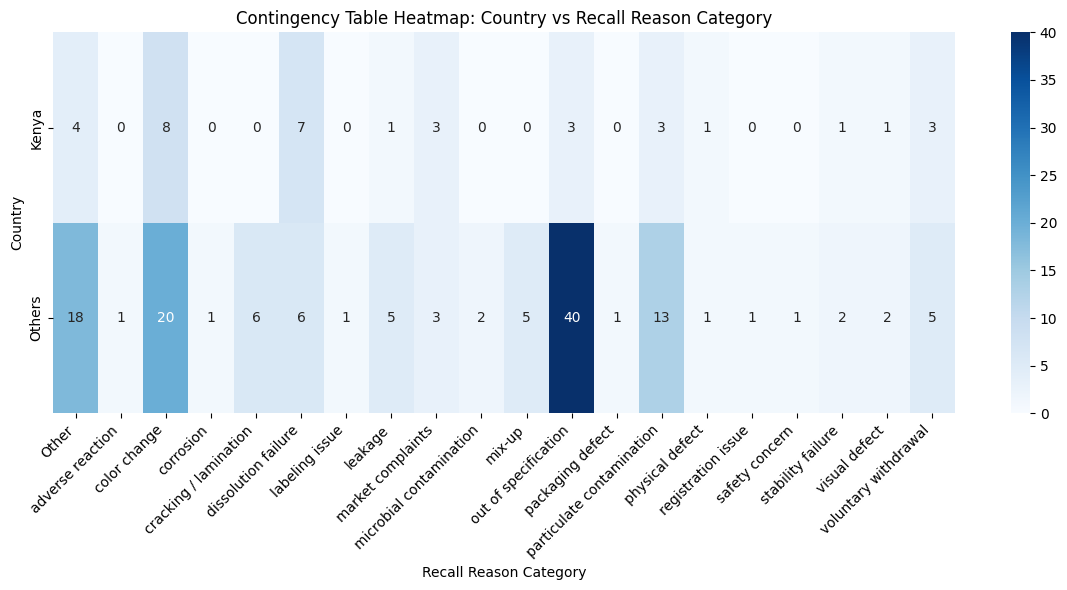

reason_category,Other,adverse reaction,color change,corrosion,cracking / lamination,dissolution failure,labeling issue,leakage,market complaints,microbial contamination,mix-up,out of specification,packaging defect,particulate contamination,physical defect,registration issue,safety concern,stability failure,visual defect,voluntary withdrawal
country_group,,,,,,,,,,,,,,,,,,,,
Kenya,4,0,8,0,0,7,0,1,3,0,0,3,0,3,1,0,0,1,1,3
Others,18,1,20,1,6,6,1,5,3,2,5,40,1,13,1,1,1,2,2,5


In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(contingency, annot=True, fmt="d", cmap="Blues")
plt.title("Contingency Table Heatmap: Country vs Recall Reason Category")
plt.ylabel("Country")
plt.xlabel("Recall Reason Category")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

contingency


## Recall Classes

| Category                 | Mapped Class     | Rationale                                                                         |
| ----------------------------- | -------------------- | --------------------------------------------------------------------------------- |
| **Microbial contamination**   | **Class I**          | High risk—potential to cause serious health harm.                                 |
| **Safety concern**            | **Class I/II**       | Depends on specifics (e.g., toxicity may be life-threatening, others reversible). |
| **Particulate contamination** | **Class II**         | May cause temporary harm or infection; typically less severe.                     |
| **Out of specification**      | **Class II**         | Could result in reduced efficacy or reversible effects.                           |
| **Visual defect**             | **Class III**        | Usually cosmetic—unlikely to cause harm.                                          |
| **Packaging defect**          | **Class III**        | Violates labeling/packaging norms, but typically not harmful.                     |
| **Leakage**                   | **Class II/III**     | Depends—can cause contamination (higher risk) or cosmetic damage.                 |
| **Mix-up**                    | **Class I/II**       | If product swapped leads to harm (e.g., wrong active ingredient), it's serious.   |
| **Cracking / lamination**     | **Class III**        | Structural issue but unlikely to cause health problems.                           |
| **Market complaints**         | — (Not classifiable) | Administrative category, doesn’t imply hazard.                                    |
| **Registration issue**        | — (Not classifiable) | Regulatory oversight—not health hazard.                                           |
| **Taste issue**               | **Class III**        | Quality concern; unlikely to harm.                                                |
| **Corrosion**                 | **Class II/III**     | Could lead to contamination (higher risk) or minor issue.                         |
| **Color change**              | **Class III**        | Cosmetic; not typically harmful.                                                  |
| **Other / Unmatched**         | **Case-by-case**     | Needs individual evaluation.                                                      |


In [47]:
recalls_df["reason_category"] = recalls_df["reason_category"].str.lower().str.strip()


In [49]:
fda_class_mapping = {
    "out of specification": "Class II",
    "dissolution failure": "Class II",
    "stability issue": "Class II",
    "stability failure": "Class II",
    "sterility failure": "Class I",
    "potency issue": "Class II",
    "dosage issue": "Class II",
    "taste issue": "Class II",
    "physical defect": "Class II",
    "missing dose": "Class II",
    "impurity issue": "Class II",
    "incorrect ingredient": "Class I",
    "foreign object": "Class I",
    "disintegration failure": "Class II",
    "contaminated solvent": "Class II",
    "flocculation": "Class II",
    "labeling issues": "Class II",
    "packaging error": "Class II",
    "incomplete pack": "Class III",
    "wrong batch print": "Class III",
    "mix-up": "Class I",
    "contamination": "Class I",
    "adverse event report": "Class I",
    "voluntary withdrawal": "Class III",
    "regulatory non-compliance": "Class III",
    "market decision": "Class III",
    "color change": "Class II",                  # usually quality/stability
    "other": "Class III",                        # non-specific, minor
    "failed quality test": "Class II",           # not directly harmful
    "microbial contamination": "Class I",        # serious health risk
    "particulate contamination": "Class I",      # can be life-threatening
    "labeling issue": "Class II",                # same as labeling issues
    "organoleptic issue": "Class II",            # taste/smell/appearance → quality
    "voluntary recall": "Class III",             # not safety-driven
    "market complaints": "Class III",            # consumer-level issues
    "packaging defect": "Class II",              # could affect quality but rarely safety
    "adverse event": "Class I",
    "adverse reaction":"Class I",                   
    "visual defect": "Class II",                 # cosmetic/appearance
    "leakage": "Class II",                       # packaging integrity issue
    "registration issue": "Class III",           # regulatory, not safety
    "cracking / lamination": "Class II",         # packaging quality
    "corrosion": "Class II",                     # stability/material degradation
    "safety concern": "Class I",                 # explicit safety risk
}


recalls_df["fda_class"] = recalls_df["reason_category"].map(fda_class_mapping)
unmapped = recalls_df[recalls_df["fda_class"].isna()]["reason_category"].unique()

print("Unmapped reason categories:")
for r in unmapped:
    print("-", r)


Unmapped reason categories:


In [50]:
recalls_df.head()

,year,date,recall_ref,product_name,inn_name,batch_no,manufacturer,reason,country_group,reason_category,fda_class
0,2016,11/12/2013,NaN,Biomol tablets,Paracetamol,All batches,Biodeal Laboratories Ltd,Color change and moulding,Kenya,color change,Class II
1,2016,24/09/2015,NaN,Beta gripe water,Gripe water,"11A, 2A, 6A, 7A, 11A",Beta Healthcare International,the batches had problems of floculation,Kenya,other,Class III
2,2016,15/06/2016,NaN,OPVERO,Oral Polio Vaccine,M5169-1,Sanofi Aventis,To replace trivalent with bivalent OPV,Others,other,Class III
3,2017,29/03/2017,NaN,Clopidogrel with Aspirin,Clopidogrel and Aspirin,E31614002,Unicure Remedies,"The product failed dissolution test, assay tes...",Others,dissolution failure,Class II
4,2017,05/04/2017,NaN,Dulcolax 5mg,Bisacodyl,160697,Boehringer,Detected Out of specification for dissolution ...,Others,out of specification,Class II


## Chi Square test for country group and recall classes

In [51]:
class_contingency = pd.crosstab(recalls_df['country_group'], recalls_df['fda_class'])
print(class_contingency)

fda_class      Class I  Class II  Class III
country_group                              
Kenya                3        22         10
Others              22        85         27


In [52]:
#chi sq test

chi2, p, dof, expected = chi2_contingency(class_contingency)

print("Chi-square statistic:", chi2)
print("Degrees of freedom:", dof)
print("p-value:", p) 

Chi-square statistic: 2.0555788861415865
Degrees of freedom: 2
p-value: 0.3577970176910091


- no significant distribution of recall classes between Kenya and other countries

In [53]:
import numpy as np

residuals = (class_contingency - expected) / np.sqrt(expected)
print(residuals)

fda_class       Class I  Class II  Class III
country_group                               
Kenya         -0.956975 -0.033939   0.844343
Others         0.489082  0.017345  -0.431520


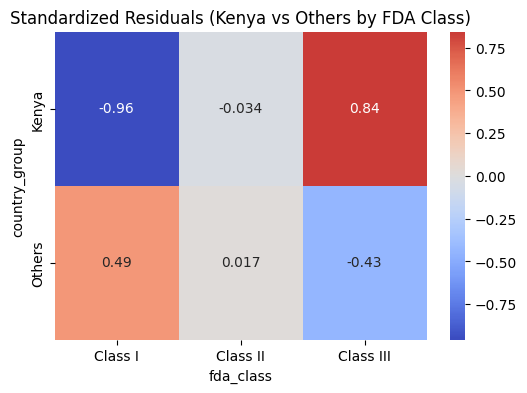

In [54]:
#plot heatmap of residuals

import seaborn as sns
plt.figure(figsize=(6,4))
sns.heatmap(residuals, annot=True, cmap="coolwarm", center=0)
plt.title("Standardized Residuals (Kenya vs Others by FDA Class)")
plt.show()


In [55]:
summary = recalls_df.groupby(['year', 'country_group', 'fda_class']).size().reset_index(name='count')
print("\nYearly Recall Counts:\n", summary.head(10))


Yearly Recall Counts:
    year country_group  fda_class  count
0  2016         Kenya   Class II      1
1  2016         Kenya  Class III      1
2  2016        Others  Class III      1
3  2017         Kenya   Class II      2
4  2017         Kenya  Class III      2
5  2017        Others    Class I      2
6  2017        Others   Class II      5
7  2018         Kenya   Class II      4
8  2018         Kenya  Class III      1
9  2018        Others    Class I      1


In [56]:
print(recalls_df['country_group'].unique())


['Kenya' 'Others']


In [57]:
recalls_df['country_group'] = recalls_df['country_group'].str.strip().str.title()

recalls_df.loc[recalls_df['country_group'] != 'Kenya', 'country_group'] = 'Others'


In [58]:
summary = recalls_df.groupby(['year', 'country_group', 'fda_class']).size().reset_index(name='count')
print("\nYearly Recall Counts:\n", summary.head(10))


Yearly Recall Counts:
    year country_group  fda_class  count
0  2016         Kenya   Class II      1
1  2016         Kenya  Class III      1
2  2016        Others  Class III      1
3  2017         Kenya   Class II      2
4  2017         Kenya  Class III      2
5  2017        Others    Class I      2
6  2017        Others   Class II      5
7  2018         Kenya   Class II      4
8  2018         Kenya  Class III      1
9  2018        Others    Class I      1


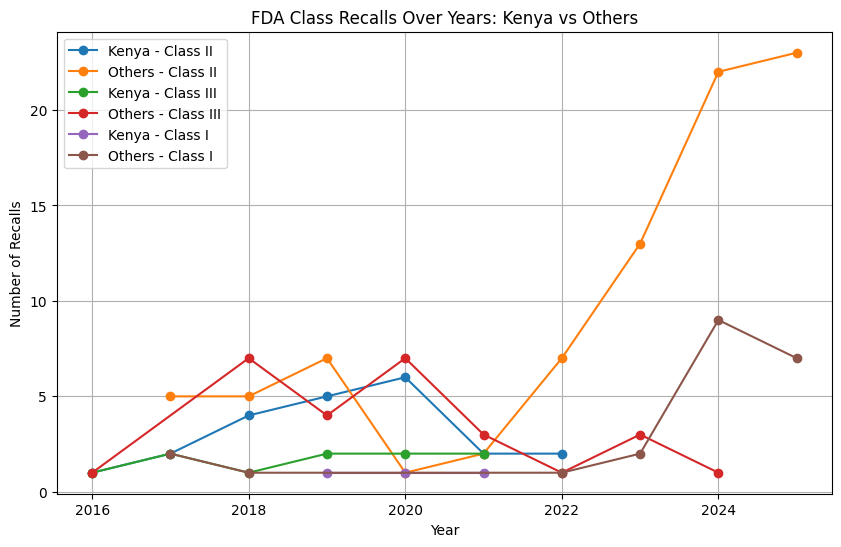

In [59]:
plt.figure(figsize=(10,6))

for fda_class in recalls_df['fda_class'].unique():
    for country in ['Kenya', 'Others']:
        country_data = summary[(summary['fda_class'] == fda_class) & (summary['country_group'] == country)]
        plt.plot(country_data['year'], country_data['count'], marker='o', label=f"{country} - {fda_class}")

plt.xlabel("Year")
plt.ylabel("Number of Recalls")
plt.title("FDA Class Recalls Over Years: Kenya vs Others")
plt.legend()
plt.grid(True)
plt.show()

Class Observation:

-class II recalls from others peaked in 2024
--Kenya class II recorded highest in 2020 but have decreased since then. 

-Class III recalls regular spikes noted.

Class I recalls recorded the same consistency for both groups, and are rare, meaning uncommon severe hazards. Could also point to strong oversight or lower reporting volume by "Others" i.e non-local manufacturers.

The spike between 2023 to 2024 could be indicative of a mass recall or regulatory action for a big market player in the "others" group. 